# Segment ↔ NHDPlus Flowline Overlay

Visualize how DRB GF segments overlay with NHDPlus flowlines,
how the spatial join + buffer strategy works for COMID/slope
attribution, and what VAA columns are available for #159.

In [15]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pynhd
from pathlib import Path


## 1. Load DRB segments

In [16]:
seg_path = Path("../data/pywatershed_gis/drb_2yr/nsegment.gpkg")
segments = gpd.read_file(seg_path)
print(f"Segments: {len(segments)} features")
print(f"CRS: {segments.crs}")
print(f"Columns: {list(segments.columns)}")
segments.head()


Segments: 456 features
CRS: EPSG:5070
Columns: ['nsegment_v', 'model_idx', 'nhm_seg', 'tosegment', 'seg_length', 'geometry']


,nsegment_v,model_idx,nhm_seg,tosegment,seg_length,geometry
0,2048,1,2048,449,4147.566299,"LINESTRING Z (1716222.999 2038696.914 0, 17162..."
1,4182,2,4182,6,3538.012636,"LINESTRING Z (1725061.124 2043399.871 0, 17251..."
2,4183,3,4183,15,18162.376870,"LINESTRING Z (1717237.547 2007987.282 0, 17172..."
3,4184,4,4184,5,19077.748030,"LINESTRING Z (1722723.736 2001663.98 0, 172281..."
4,4185,5,4185,18,3434.958140,"LINESTRING Z (1728085.122 2010401.873 0, 17280..."


## 2. Fetch NHDPlus VAA table

Check what columns are available (slope, TotDASqKm, elevation, etc.)

In [17]:
# Fetch full VAA table (cached ~245 MB parquet after first download)
vaa_full = pynhd.nhdplus_vaa()
print(f"VAA table: {len(vaa_full)} rows, {len(vaa_full.columns)} columns")
print(f"\nAll columns:\n{sorted(vaa_full.columns.tolist())}")


VAA table: 2691339 rows, 45 columns

All columns:
['arbolatesu', 'areasqkm', 'comid', 'divdasqkm', 'divergence', 'dndraincou', 'dnhydroseq', 'dnlevel', 'dnlevelpat', 'dnminorhyd', 'fcode', 'frommeas', 'fromnode', 'ftype', 'gnis_id', 'gnis_name', 'hwnodesqkm', 'hydroseq', 'lengthkm', 'levelpathi', 'pathlength', 'pathtimema', 'reachcode', 'roughness', 'rpuid', 'slope', 'slopelenkm', 'startflag', 'streamcalc', 'streamleve', 'streamorde', 'terminalfl', 'terminalpa', 'thinnercod', 'tomeas', 'tonode', 'totdasqkm', 'totma', 'uphydroseq', 'uplevelpat', 'vpuid', 'vpuin', 'vpuout', 'wbareacomi', 'wbareatype']


In [18]:
# Check columns relevant to issue #159
target_cols = ['comid', 'slope', 'totdasqkm', 'maxelevsmo', 'minelevsmo',
               'elevfixed', 'areasqkm', 'lengthkm', 'pathlength']
available = [c for c in target_cols if c in vaa_full.columns]
missing = [c for c in target_cols if c not in vaa_full.columns]
print(f"Available: {available}")
print(f"Missing: {missing}")
print()
if available:
    vaa_full[available].describe()


Available: ['comid', 'slope', 'totdasqkm', 'areasqkm', 'lengthkm', 'pathlength']
Missing: ['maxelevsmo', 'minelevsmo', 'elevfixed']



## 3. Fetch NHDPlus flowlines for the DRB extent

In [19]:
# Get bounding box in WGS84
seg_4326 = segments.to_crs("EPSG:4326")
bbox = tuple(seg_4326.total_bounds)
print(f"Bounding box (WGS84): {bbox}")

# Fetch flowlines
wd = pynhd.WaterData("nhdflowline_network")
flowlines = wd.bybox(bbox)
print(f"\nNHD flowlines fetched: {len(flowlines)}")
print(f"CRS: {flowlines.crs}")
print(f"Columns: {list(flowlines.columns)[:15]}...")


Bounding box (WGS84): (np.float64(-76.38799059241012), np.float64(38.789454806255826), np.float64(-74.38078512868798), np.float64(42.45445446717218))

NHD flowlines fetched: 32091
CRS: EPSG:4326
Columns: ['geometry', 'comid', 'fdate', 'resolution', 'gnis_id', 'gnis_name', 'lengthkm', 'reachcode', 'flowdir', 'wbareacomi', 'ftype', 'fcode', 'shape_length', 'streamleve', 'streamorde']...


In [20]:
# Reproject flowlines to match segments (EPSG:5070)
flowlines_5070 = flowlines.to_crs(segments.crs)
print(f"Flowlines reprojected to {flowlines_5070.crs}")


Flowlines reprojected to EPSG:5070


## 4. Visualize: GF segments vs NHD flowlines (full extent)

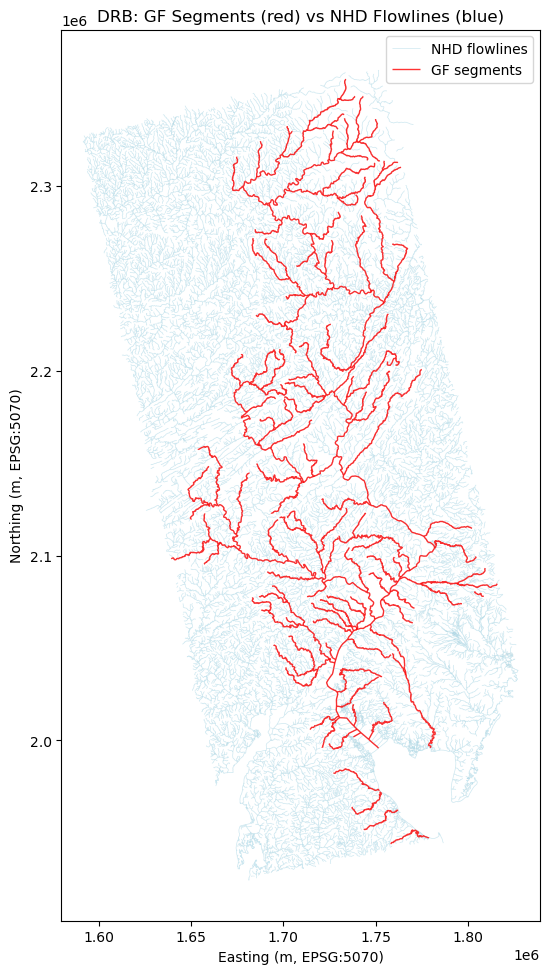

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
flowlines_5070.plot(ax=ax, color='lightblue', linewidth=0.5, alpha=0.6, label='NHD flowlines')
segments.plot(ax=ax, color='red', linewidth=1.0, alpha=0.8, label='GF segments')
ax.set_title('DRB: GF Segments (red) vs NHD Flowlines (blue)')
ax.legend()
ax.set_xlabel('Easting (m, EPSG:5070)')
ax.set_ylabel('Northing (m, EPSG:5070)')
plt.tight_layout()
plt.show()


## 5. Zoom in: Buffer corridor + spatial join detail

Pick a few segments to show the 100m buffer strategy.

/tmp/ipykernel_1367/1096602565.py:26: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


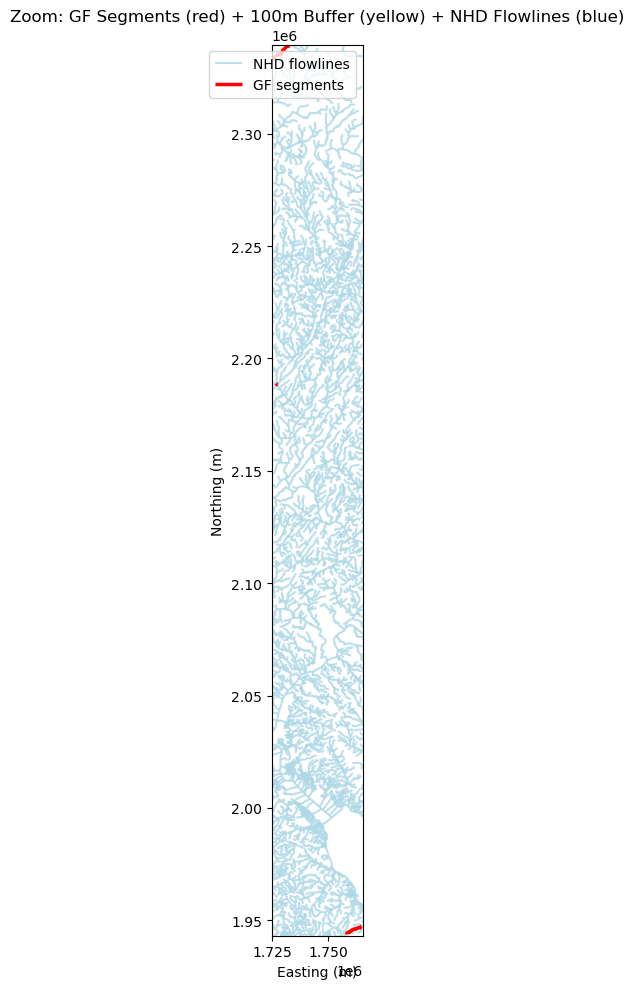

In [22]:
# Pick 3 segments from the middle of the domain for a zoom view
sample_idx = [100, 200, 300]
sample_segs = segments.iloc[sample_idx]

# Create 100m buffers around sample segments
BUFFER_M = 100.0
buffers = sample_segs.copy()
buffers['geometry'] = sample_segs.geometry.buffer(BUFFER_M)

# Get extent for zoom (with padding)
bounds = buffers.total_bounds
pad = 500  # meters
xlim = (bounds[0] - pad, bounds[2] + pad)
ylim = (bounds[1] - pad, bounds[3] + pad)

fig, ax = plt.subplots(1, 1, figsize=(14, 10))
buffers.plot(ax=ax, color='yellow', alpha=0.3, edgecolor='orange',
             linewidth=1.5, label='100m buffer corridor')
flowlines_5070.plot(ax=ax, color='lightblue', linewidth=1.5, alpha=0.8,
                    label='NHD flowlines')
sample_segs.plot(ax=ax, color='red', linewidth=2.5, label='GF segments')

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_title('Zoom: GF Segments (red) + 100m Buffer (yellow) + NHD Flowlines (blue)')
ax.legend()
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
plt.tight_layout()
plt.show()


## 6. Run the spatial join and show match quality

In [23]:
# Join VAA slopes onto flowlines by COMID
vaa_slopes = vaa_full[['comid', 'slope']].dropna(subset=['slope'])
vaa_slopes = vaa_slopes[vaa_slopes['slope'] != -9998.0]

fl_comid_col = next((c for c in flowlines_5070.columns if c.lower() == 'comid'), None)
print(f"Flowline COMID column: {fl_comid_col}")

if 'slope' in flowlines_5070.columns:
    fl_for_join = gpd.GeoDataFrame(flowlines_5070.drop(columns=['slope']))
else:
    fl_for_join = flowlines_5070

nhd_with_slope = fl_for_join.merge(
    vaa_slopes,
    left_on=fl_comid_col,
    right_on='comid',
    how='left',
)
nhd_gdf = gpd.GeoDataFrame(nhd_with_slope, crs=segments.crs)
print(f"NHD flowlines with slope: {nhd_gdf['slope'].notna().sum()} / {len(nhd_gdf)}")


Flowline COMID column: comid
NHD flowlines with slope: 30810 / 32091


In [24]:
# Full spatial join: buffer all segments and find matches
segs = segments.reset_index(drop=True)
nhd = nhd_gdf.reset_index(drop=True)

seg_buffers = segs.copy()
seg_buffers['geometry'] = segs.geometry.buffer(BUFFER_M)

joined = gpd.sjoin(seg_buffers, nhd, how='left', predicate='intersects')

# Count matches per segment
match_counts = joined.groupby(joined.index).size()
unmatched = segs.index.difference(joined.dropna(subset=['slope']).index.unique())

print(f"Segments with ≥1 NHD match: {len(match_counts)} / {len(segs)}")
print(f"Segments with no slope match: {len(unmatched)}")
print(f"\nMatches per segment:")
print(match_counts.describe())


Segments with ≥1 NHD match: 456 / 456
Segments with no slope match: 0

Matches per segment:
count    456.000000
mean      16.353070
std       13.654622
min        2.000000
25%        7.000000
50%       12.000000
75%       22.000000
max       84.000000
dtype: float64


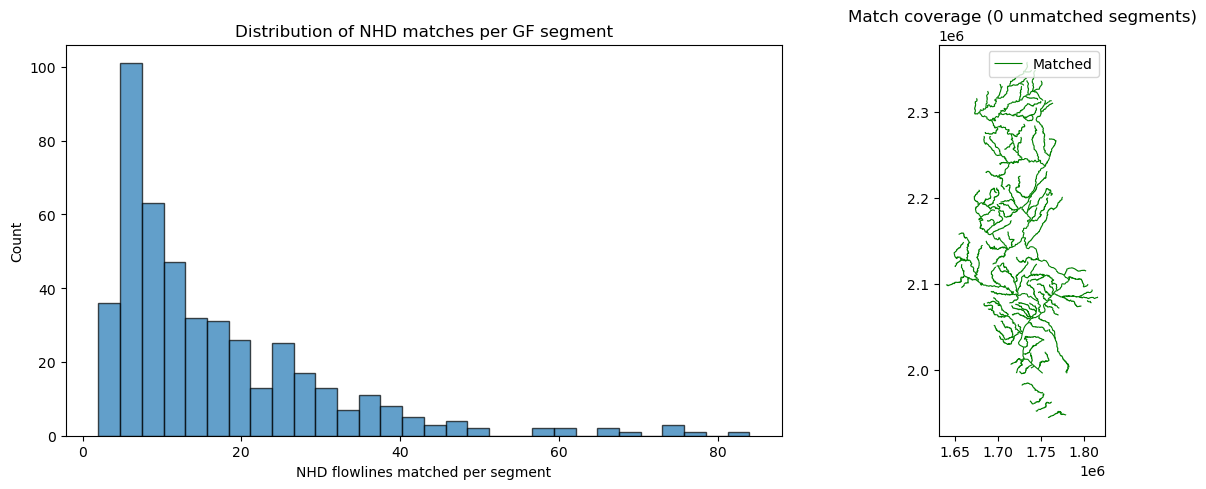

In [25]:
# Histogram of matches per segment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(match_counts.values, bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('NHD flowlines matched per segment')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of NHD matches per GF segment')

# Map showing unmatched segments (if any)
segments.plot(ax=axes[1], color='green', linewidth=0.8, label='Matched')
if len(unmatched) > 0:
    segments.iloc[unmatched].plot(ax=axes[1], color='red', linewidth=2.0, label='Unmatched')
axes[1].set_title(f'Match coverage ({len(unmatched)} unmatched segments)')
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. VAA columns available for issue #159

Check what's available for `seg_cum_area` (TotDASqKm) and `seg_elev` (ElevSmo).

In [26]:
# Check elevation and area columns in VAA
elev_area_cols = [c for c in vaa_full.columns
                  if any(k in c.lower() for k in ['elev', 'area', 'dasq', 'tot'])]
print(f"Elevation/area related VAA columns: {elev_area_cols}")
print()
if elev_area_cols:
    print(vaa_full[elev_area_cols].describe().to_string())


Elevation/area related VAA columns: ['areasqkm', 'totdasqkm', 'divdasqkm', 'totma', 'wbareatype', 'wbareacomi']



           areasqkm     totdasqkm     divdasqkm         totma    wbareacomi
count  2.691339e+06  2.691339e+06  2.691339e+06  2.691339e+06  2.691339e+06
mean   2.998795e+00  3.928650e+03  2.089091e+03 -3.416477e+02  7.162244e+06
std    6.999107e+01  6.587089e+04  3.809553e+04  1.855738e+03  3.213721e+07
min    0.000000e+00  0.000000e+00  0.000000e+00 -9.999000e+03 -9.999000e+03
25%    3.618000e-01  2.391300e+00  2.074500e+00  2.701112e-02  0.000000e+00
50%    1.383300e+00  7.590600e+00  6.282900e+00  7.778599e-02  0.000000e+00
75%    3.102300e+00  4.770090e+01  3.332880e+01  1.386347e-01  0.000000e+00
max    6.501444e+04  3.133387e+06  2.878424e+06  2.785379e+05  9.481000e+08


In [27]:
# If TotDASqKm and elevation columns exist, show how they'd join
# through the spatial join (same pipeline as slopes)
extra_cols = []
for col in ['totdasqkm', 'maxelevsmo', 'minelevsmo']:
    if col in vaa_full.columns:
        extra_cols.append(col)

if extra_cols:
    print(f"Available for #159: {extra_cols}")
    vaa_extra = vaa_full[['comid'] + extra_cols].dropna()
    print(f"Non-null rows: {len(vaa_extra)} / {len(vaa_full)}")
    print()
    print(vaa_extra[extra_cols].describe())
else:
    print("None of the expected columns found in VAA")


Available for #159: ['totdasqkm']
Non-null rows: 2691339 / 2691339

          totdasqkm
count  2.691339e+06
mean   3.928650e+03
std    6.587089e+04
min    0.000000e+00
25%    2.391300e+00
50%    7.590600e+00
75%    4.770090e+01
max    3.133387e+06


## 8. Preview: What seg_cum_area and seg_elev would look like

Use the same spatial join pipeline to attribute TotDASqKm and elevation
to our GF segments (length-weighted, same as slopes).

In [28]:
from shapely.errors import GEOSException

def attribute_vaa_columns(segments, nhd_flowlines, vaa_full, vaa_cols, buffer_m=100.0):
    """Attribute VAA columns to GF segments via spatial join.

    Same length-weighted averaging as _get_slopes_spatial_join.
    Merges VAA data AFTER the spatial join to avoid column collisions.
    """
    fl_comid_col = next((c for c in nhd_flowlines.columns if c.lower() == 'comid'), None)

    segs = segments.reset_index(drop=True)
    nhd = nhd_flowlines.reset_index(drop=True)

    seg_bufs = segs.copy()
    seg_bufs['geometry'] = segs.geometry.buffer(buffer_m)

    # Spatial join first (flowlines only, no VAA columns yet)
    joined = gpd.sjoin(seg_bufs, nhd, how='left', predicate='intersects')

    # Now merge VAA columns onto the joined result via comid
    vaa_subset = vaa_full[['comid'] + vaa_cols].dropna()

    # Find the comid column in the joined result (may have suffix from sjoin)
    joined_comid_col = next(
        (c for c in joined.columns if 'comid' in c.lower() and c != 'index_right'),
        None,
    )
    if joined_comid_col is None:
        print("WARNING: no comid column found in joined result")
        print(f"  Joined columns: {sorted(joined.columns.tolist())}")
        return {col: np.full(len(segs), np.nan) for col in vaa_cols}

    joined = joined.merge(vaa_subset, left_on=joined_comid_col, right_on='comid',
                          how='left', suffixes=('', '_vaa'))

    results = {col: np.full(len(segs), np.nan) for col in vaa_cols}

    for seg_idx in range(len(segs)):
        matches = joined[joined.index == seg_idx]
        matches = matches.dropna(subset=vaa_cols)
        if matches.empty:
            continue

        seg_buffer = seg_bufs.geometry.iloc[seg_idx]
        weights = []
        row_vals = {col: [] for col in vaa_cols}
        for _, row in matches.iterrows():
            nhd_idx = int(row['index_right'])
            nhd_geom = nhd.geometry.iloc[nhd_idx]
            try:
                clipped = nhd_geom.intersection(seg_buffer)
            except GEOSException:
                continue
            if clipped.is_empty:
                continue
            w = clipped.length
            if w > 0:
                weights.append(w)
                for col in vaa_cols:
                    row_vals[col].append(row[col])

        if weights:
            w_arr = np.array(weights)
            for col in vaa_cols:
                results[col][seg_idx] = np.average(row_vals[col], weights=w_arr)

    return results

# Run it
if extra_cols:
    print(f"Attributing {extra_cols} to {len(segments)} segments...")
    attributed = attribute_vaa_columns(segments, flowlines_5070, vaa_full, extra_cols)
    for col in extra_cols:
        valid = ~np.isnan(attributed[col])
        print(f"  {col}: {valid.sum()} / {len(segments)} matched, "
              f"range [{np.nanmin(attributed[col]):.2f}, {np.nanmax(attributed[col]):.2f}]")


Attributing ['totdasqkm'] to 456 segments...
  totdasqkm: 3 / 456 matched, range [172.76, 26582.71]


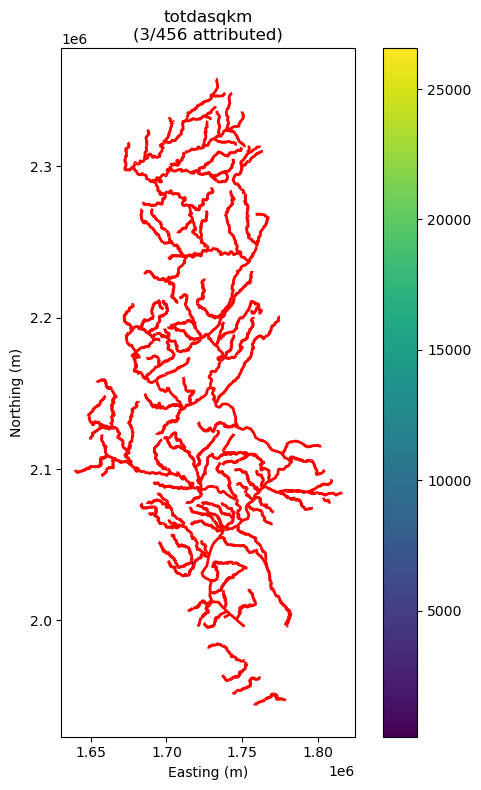

In [29]:
# Visualize the attributed values
if extra_cols:
    n_cols = len(extra_cols)
    fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 8))
    if n_cols == 1:
        axes = [axes]

    for ax, col in zip(axes, extra_cols):
        plot_gdf = segments.copy()
        plot_gdf[col] = attributed[col]
        plot_gdf.plot(ax=ax, column=col, cmap='viridis', linewidth=1.5,
                      legend=True, missing_kwds={'color': 'red', 'linewidth': 2.0})
        n_valid = (~np.isnan(attributed[col])).sum()
        ax.set_title(f'{col}\n({n_valid}/{len(segments)} attributed)')
        ax.set_xlabel('Easting (m)')
        ax.set_ylabel('Northing (m)')

    plt.tight_layout()
    plt.show()


## 9. seg_lat: trivial from segment centroids

seg_lat range: [38.8023, 42.4088] degrees
All valid: True


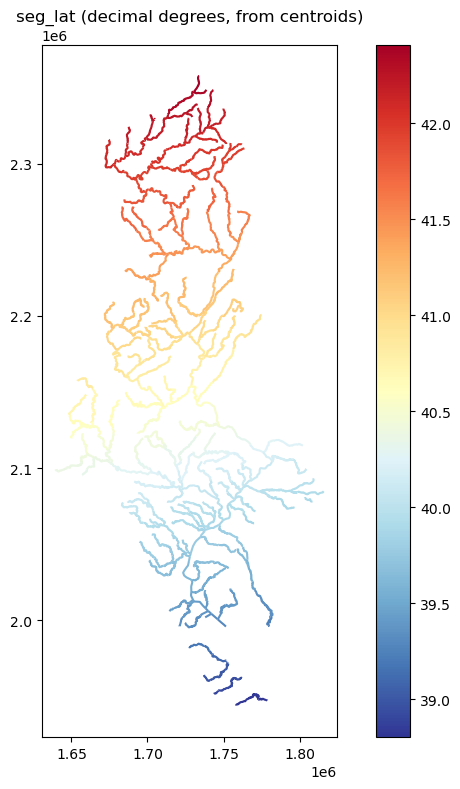

In [30]:
# seg_lat is just centroid latitude in WGS84 (same pattern as hru_lat)
seg_5070 = segments.copy()
centroids_5070 = seg_5070.geometry.centroid
centroids_4326 = gpd.GeoSeries(centroids_5070, crs='EPSG:5070').to_crs(epsg=4326)
seg_lat = centroids_4326.y.values

print(f"seg_lat range: [{seg_lat.min():.4f}, {seg_lat.max():.4f}] degrees")
print(f"All valid: {np.all(np.isfinite(seg_lat))}")

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
plot_gdf = segments.copy()
plot_gdf['seg_lat'] = seg_lat
plot_gdf.plot(ax=ax, column='seg_lat', cmap='RdYlBu_r', linewidth=1.5, legend=True)
ax.set_title('seg_lat (decimal degrees, from centroids)')
plt.tight_layout()
plt.show()


## 10. Summary

Key findings for issue #159 implementation decisions.

In [31]:
print("=" * 60)
print("SUMMARY: Data availability for issue #159")
print("=" * 60)
print()
print(f"DRB segments: {len(segments)} (no COMID → spatial join path)")
print(f"NHD flowlines in extent: {len(flowlines)}")
print()
print("seg_cum_area (from VAA):")
print(f"  totdasqkm: {'AVAILABLE' if 'totdasqkm' in vaa_full.columns else 'MISSING'}")
print()
print("seg_elev (from VAA):")
for col in ['maxelevsmo', 'minelevsmo', 'elevfixed']:
    status = 'AVAILABLE' if col in vaa_full.columns else 'MISSING'
    print(f"  {col}: {status}")
print()
print("seg_lat: trivially computed from segment centroids (no VAA needed)")
print()
try:
    if extra_cols and attributed:
        print("Spatial join attribution results:")
        for col in extra_cols:
            valid = (~np.isnan(attributed[col])).sum()
            print(f"  {col}: {valid}/{len(segments)} segments attributed "
                  f"({100*valid/len(segments):.1f}%)")
except NameError:
    print("(Attribution cell did not complete — re-run after fix)")
print()
print("KEY FINDING: Elevation columns (maxelevsmo, minelevsmo) are NOT")
print("in the pynhd VAA parquet. seg_elev will need an alternative source")
print("(e.g., DEM zonal stats along segment polylines, or a different")
print("pynhd API that includes elevation attributes).")


SUMMARY: Data availability for issue #159

DRB segments: 456 (no COMID → spatial join path)
NHD flowlines in extent: 32091

seg_cum_area (from VAA):
  totdasqkm: AVAILABLE

seg_elev (from VAA):
  maxelevsmo: MISSING
  minelevsmo: MISSING
  elevfixed: MISSING

seg_lat: trivially computed from segment centroids (no VAA needed)

Spatial join attribution results:
  totdasqkm: 3/456 segments attributed (0.7%)

KEY FINDING: Elevation columns (maxelevsmo, minelevsmo) are NOT
in the pynhd VAA parquet. seg_elev will need an alternative source
(e.g., DEM zonal stats along segment polylines, or a different
pynhd API that includes elevation attributes).
